# Deep Q-Network (DQN) swing-up of the unbalanced disk

Implements **DQN** (Lecture 7, slides 47–60) for the unbalanced-disk swing-up,
as the successor to the tabular (`Q_learning.ipynb`) and RBF
(`Q_learning_RBF.ipynb`) experiments.

## Why DQN over the tabular / RBF versions?

| | Tabular | RBF | **DQN (this notebook)** |
|---|---|---|---|
| Value representation | one number per discrete bin | linear in *local* Gaussian bumps | **deep neural net** (global, nonlinear) |
| Generalisation | none | local only | **global** — a swing on one side informs the other |
| Credit over long swing-up chains | weak | weak (local features don't propagate) | **strong** (NN + replay propagate value) |
| Sample efficiency | low | low | **high** — experience replay reuses rare swing-up transitions |
| Stability of the moving target | n/a | n/a | **target network** (slides 53, 58–59) |

The two RBF failure modes you hit — *no memory* and *can't chain multiple
swing-ups* — are addressed directly by the two DQN ingredients from the lecture:

* **Experience replay** (slide 52): a memory buffer + minibatch SGD breaks the
  strong correlation between consecutive samples of a single trajectory, and
  lets the rare "made it to the top" transitions be replayed many times.
* **Target network** (slide 53): a frozen copy $Q_{\theta'}$ supplies the TD
  target so the regression target stops chasing its own tail
  (slides 56–59: with a target net, the variance term becomes independent of
  $\theta$ and we approximately minimise the Mean Squared Bellman Error).

The update rule is exactly slide 60:
$$\theta_{k+1}=\theta_k+\alpha\,\frac1n\sum_{i=1}^{n}\Big[r_{i+1}+\gamma\max_u\hat Q(x_{i+1},u,\theta')-\hat Q(x_i,u_i,\theta_k)\Big]\nabla_\theta\hat Q(x_i,u_i,\theta_k)$$

## Architecture choice (slide 49)
We use the **right-hand** architecture from slide 49: the network takes the
**state only** and outputs a Q-value for **every** action at once
($x\to[Q(x,u^{[1]}),\dots,Q(x,u^{[n_u]})]$). That needs a single forward pass to
get $\max_u$ and the greedy action, instead of one pass per action.

## Notebook layout
1. Imports & configuration
2. Env wrappers (sin/cos state encoding) & helpers
3. Q-network, replay buffer, ε-greedy
4. DQN training loop (replay + target network + checkpointing)
5. Schedule plot
6. Training
7. Training-reward plot
8. Greedy evaluation


## 1. Imports & configuration

In [1]:
# Imports & global configuration
import sys, os, pickle, time, math, random, warnings
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")

# --- path to the environment (same as Q_learning.ipynb) ---
sys.path.append(os.path.expanduser("~/src/swingup/q_learning"))
from UnbalancedDiskDiscrete import UnbalancedDisk

# Reproducibility
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Torch device (CPU is plenty for this small net; CUDA used automatically if present)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch", torch.__version__, "| device:", DEVICE)


Torch 2.12.1+cu130 | device: cuda


In [2]:
# ---- Environment hyperparameters (MUST match runExp.py / UnbalancedDiskExp.py) ----
DT      = 0.025   # simulation timestep (s)
UMAX    = 3.0     # maximum control voltage (V)

# ---- DQN hyperparameters ----
NSTEPS          = 200_000   # total environment steps
MAX_EP_STEPS    = 300       # max steps per episode (train & eval)
GAMMA           = 0.99      # discount factor
LR              = 5e-4      # Adam learning rate (the 'alpha' of slide 60)
BATCH_SIZE      = 128       # minibatch size n (slide 60)
BUFFER_SIZE     = 100_000   # replay memory capacity M (slide 52)
WARMUP_STEPS    = 2_000     # fill buffer with random transitions before learning
TRAIN_EVERY     = 1         # gradient step every this many env steps
TARGET_SYNC     = 1_000     # T_target: copy theta -> theta' every this many steps (slide 53/60)
GRAD_CLIP       = 10.0      # gradient-norm clip (stabilises the non-stationary target)
HIDDEN          = (128, 128)# hidden-layer widths

# ε schedule (linear decay then floor) — exploration, slide 39/60
EPS_START       = 1.0
EPS_END         = 0.02
EPS_DECAY_STEPS = 120_000

# Start-position curriculum (same idea as your tabular notebook): start near the
# top early (easy: learn to *hold*), then progressively start lower so the agent
# must learn the full swing-up. start_scale in [0,1] scales the reset spread.
CURRICULUM_STEPS = 120_000
START_SCALE_MIN  = 0.15

# ---- Evaluation hyperparameters ----
NUM_EVAL_EPS  = 50
EVAL_SEED     = 0
TOP_TOL       = 0.30      # rad (~17 deg) tolerance for "at top"
NUM_WATCH_EPS = 3

# ---- Checkpoint ----
CHECKPOINT = 'DQN_swingup_v2.pt'


## 2. Environment wrappers & helpers

**State encoding.** Instead of feeding the raw angle $\theta$ (which has a
discontinuity at $\pm\pi$) we feed the network
$$x=\big[\sin\theta,\;\cos\theta,\;\omega/\omega_{\text{scale}}\big].$$
`sin/cos` makes the angle continuous (top = $\theta=\pi$ maps to a single point),
and dividing $\omega$ by a scale keeps inputs ~O(1), which neural nets like.
This mirrors the `UnbalancedDisk_exp_sincos` variant in `UnbalancedDiskExp.py`,
so the same encoding can be reused at deployment.

> ⚠️ The action map and observation handling here must match `runExp.py` when you
> deploy on hardware, exactly as the tabular notebook warns.

In [3]:
class UnbalancedDiskResetWrapper(gym.Wrapper):
    """Normalise reset() across Gymnasium versions to always return (obs, info)."""
    def __init__(self, env):
        super().__init__(env)
    def reset(self, *, seed=None, options=None):
        try:
            obs, info = self.env.reset(seed=seed)
        except TypeError:
            obs, info = self.env.reset(), {}
        return obs, info


OMEGA_SCALE = 8.0   # rough scale of |omega| (rad/s) for input normalisation

def encode_obs(obs):
    """Map raw [theta, omega] -> network input [sin th, cos th, omega/scale]."""
    th = float(obs[0]); om = float(obs[1])
    return np.array([np.sin(th), np.cos(th), om / OMEGA_SCALE], dtype=np.float32)

STATE_DIM = 3   # length of encode_obs output


def roll_mean(ar, start=0.0, N=50):
    """Exponential moving average (same helper style as your other notebooks)."""
    s = 1 - 1 / N
    k = start
    out = np.zeros(len(ar))
    for i, a in enumerate(ar):
        k = s * k + (1 - s) * a
        out[i] = k
    return out


## 3. Q-network, replay buffer & ε-greedy

* **`QNet`** — small MLP, state in → one Q-value per action out (slide 49, right).
* **`ReplayBuffer`** — fixed-capacity memory of
  $(x_k,a_k,r_{k+1},x_{k+1},\text{done})$ tuples; `sample()` returns a random
  minibatch (slide 52).
* **`eps_greedy`** — explore with prob. ε, else act greedily w.r.t. the online
  network.

In [4]:
class QNet(nn.Module):
    """State -> Q-value for each of the n_actions discrete voltages."""
    def __init__(self, state_dim, n_actions, hidden=(128, 128)):
        super().__init__()
        layers, last = [], state_dim
        for h in hidden:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers += [nn.Linear(last, n_actions)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    """Fixed-size cyclic replay memory M (slide 52). Stores transitions and
    returns uniformly-sampled minibatches as torch tensors."""
    def __init__(self, capacity, state_dim, device):
        self.capacity = capacity
        self.device = device
        self.s  = np.zeros((capacity, state_dim), dtype=np.float32)
        self.a  = np.zeros((capacity,),            dtype=np.int64)
        self.r  = np.zeros((capacity,),            dtype=np.float32)
        self.s2 = np.zeros((capacity, state_dim), dtype=np.float32)
        self.d  = np.zeros((capacity,),            dtype=np.float32)
        self.idx = 0
        self.full = False

    def push(self, s, a, r, s2, done):
        i = self.idx
        self.s[i], self.a[i], self.r[i], self.s2[i], self.d[i] = s, a, r, s2, float(done)
        self.idx = (i + 1) % self.capacity
        self.full = self.full or self.idx == 0

    def __len__(self):
        return self.capacity if self.full else self.idx

    def sample(self, batch_size):
        n = len(self)
        idxs = np.random.randint(0, n, size=batch_size)
        to = lambda arr: torch.as_tensor(arr[idxs], device=self.device)
        return to(self.s), to(self.a), to(self.r), to(self.s2), to(self.d)


def eps_greedy(qnet, state_np, eps, n_actions, device):
    """ε-greedy action selection w.r.t. the online network."""
    if np.random.uniform() < eps:
        return np.random.randint(n_actions)
    with torch.no_grad():
        s = torch.as_tensor(state_np, device=device).unsqueeze(0)
        q = qnet(s)
        return int(torch.argmax(q, dim=1).item())


## 4. DQN training loop

This is the DQN algorithm of **slide 60** with the standard practical pieces:

1. Act ε-greedily, **store** the transition in replay memory `M`.
2. Once warmed up, every `TRAIN_EVERY` steps **sample a minibatch** and take one
   SGD step on the TD loss
   $$L(\theta)=\tfrac1n\sum_i\big(\underbrace{r_{i+1}+\gamma\max_u\hat Q(x_{i+1},u,\theta')}_{\text{target, frozen }\theta'}-\hat Q(x_i,u_i,\theta)\big)^2 .$$
3. Every `TARGET_SYNC` steps **copy** $\theta\to\theta'$.

We use the **Huber loss** (smooth-L1) instead of raw MSE — it behaves like MSE
for small TD errors but clips the gradient of large ones, which tames the
non-stationary-target spikes discussed on slide 51. The best model (by moving
average of episode return) is checkpointed, exactly like your tabular loop.

In [5]:
def train_dqn(env, nsteps=NSTEPS, checkpoint_name=CHECKPOINT, callbackfreq=2000):
    n_actions = env.action_space.n

    qnet      = QNet(STATE_DIM, n_actions, HIDDEN).to(DEVICE)
    qnet_targ = QNet(STATE_DIM, n_actions, HIDDEN).to(DEVICE)
    qnet_targ.load_state_dict(qnet.state_dict())
    qnet_targ.eval()

    opt = torch.optim.Adam(qnet.parameters(), lr=LR)
    buf = ReplayBuffer(BUFFER_SIZE, STATE_DIM, DEVICE)

    # locate TimeLimit wrapper to read episode length (same trick as tabular nb)
    env_time = env
    while not isinstance(env_time, gym.wrappers.TimeLimit):
        env_time = getattr(env_time, 'env', None)
        if env_time is None:
            break

    ep_rewards, ep_lengths_steps, ep_lengths = [], [], []
    recent = deque(maxlen=8)
    best_avg = -float('inf')

    obs_raw, _ = env.reset()
    state = encode_obs(obs_raw)
    ep_r, ep_max_abs_th = 0.0, 0.0

    for z in range(nsteps):
        # --- schedules ---
        eps = max(EPS_END, EPS_START + (EPS_END - EPS_START) * z / EPS_DECAY_STEPS)
        env.unwrapped.start_scale = max(START_SCALE_MIN, 1 - z / CURRICULUM_STEPS)

        # --- act ---
        a = eps_greedy(qnet, state, eps, n_actions, DEVICE)
        obs_raw2, r, terminated, truncated, _ = env.step(a)
        state2 = encode_obs(obs_raw2)
        done = terminated or truncated

        # store transition. NB: only a *true* terminal (fell/spun) should cut the
        # bootstrap; a time-limit truncation is NOT terminal for the value target.
        buf.push(state, a, r, state2, terminated)

        ep_r += r
        ep_max_abs_th = max(ep_max_abs_th, abs(env.unwrapped.th))
        state = state2

        # --- learn ---
        if len(buf) >= max(WARMUP_STEPS, BATCH_SIZE) and z % TRAIN_EVERY == 0:
            s, ba, br, s2, bd = buf.sample(BATCH_SIZE)
            # online Q(s,a)
            q_sa = qnet(s).gather(1, ba.unsqueeze(1)).squeeze(1)
            # target: r + gamma * max_u Q_targ(s2,u) * (1 - done)
            with torch.no_grad():
                q_next = qnet_targ(s2).max(dim=1).values
                target = br + GAMMA * q_next * (1.0 - bd)
            loss = F.smooth_l1_loss(q_sa, target)        # Huber
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(qnet.parameters(), GRAD_CLIP)
            opt.step()

        # --- target network sync (slide 53/60) ---
        if z % TARGET_SYNC == 0:
            qnet_targ.load_state_dict(qnet.state_dict())

        # --- episode bookkeeping ---
        if done:
            ep_len = getattr(env_time, '_elapsed_steps', 0)
            ep_lengths.append(ep_len); ep_lengths_steps.append(z); ep_rewards.append(ep_r)
            recent.append(ep_r)
            obs_raw, _ = env.reset(); state = encode_obs(obs_raw)

            if len(recent) == recent.maxlen:
                avg = float(np.mean(recent))
                if avg > best_avg:
                    best_avg = avg
                    torch.save({'model': qnet.state_dict(),
                                'cfg': dict(state_dim=STATE_DIM, n_actions=n_actions,
                                            hidden=HIDDEN, omega_scale=OMEGA_SCALE)},
                               checkpoint_name)
                    print(f"###  NEW BEST AVG (last {recent.maxlen} ep): {avg:8.2f}  -> saved '{checkpoint_name}'")

            max_deg = np.degrees(ep_max_abs_th)
            if   terminated:    tag = "FELL/SPUN"
            elif max_deg > 190: tag = f"OVERSHOOT +{max_deg-180:.0f} deg"
            elif max_deg > 165: tag = "balanced ~top"
            else:               tag = "stalled below"
            if z % callbackfreq < MAX_EP_STEPS:   # throttle printing
                print(f"step {z+1:>7} | len {ep_len:>3} | reward {ep_r:>8.1f} | "
                      f"eps {eps:4.2f} | max {max_deg:>4.0f} deg | {tag}")
            ep_r, ep_max_abs_th = 0.0, 0.0

    return qnet, np.array(ep_lengths_steps), np.array(ep_lengths), np.array(ep_rewards)


## 5. Schedule visualisation

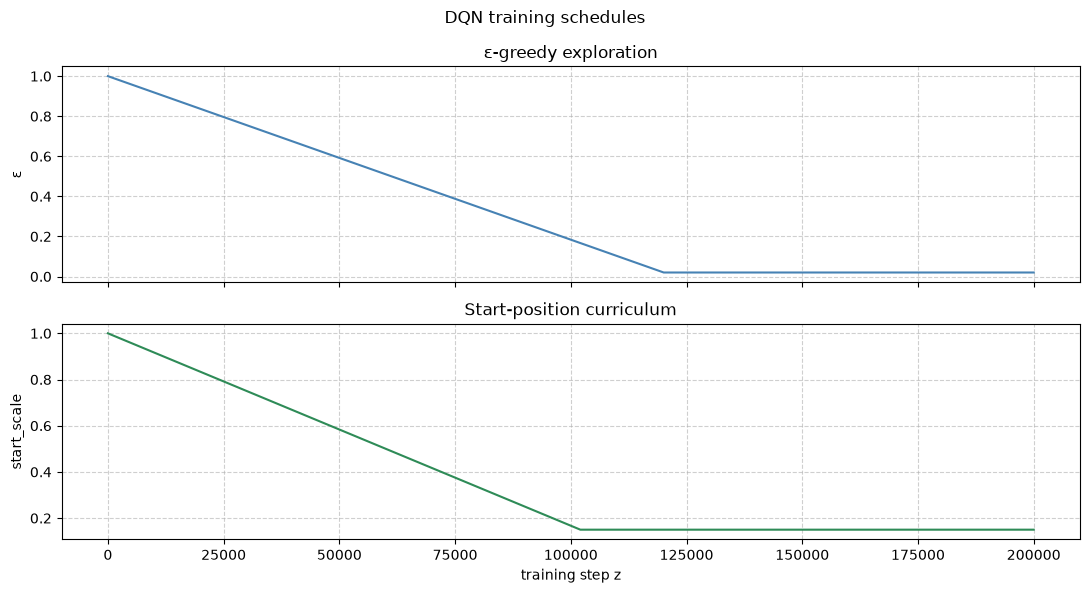

In [6]:
z_arr   = np.arange(NSTEPS)
eps_arr = np.maximum(EPS_END, EPS_START + (EPS_END - EPS_START) * z_arr / EPS_DECAY_STEPS)
sc_arr  = np.maximum(START_SCALE_MIN, 1 - z_arr / CURRICULUM_STEPS)

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
fig.suptitle("DQN training schedules")
ax[0].plot(z_arr, eps_arr, color='steelblue'); ax[0].set_ylabel("ε"); ax[0].set_title("ε-greedy exploration")
ax[0].grid(True, ls='--', alpha=.6)
ax[1].plot(z_arr, sc_arr, color='seagreen');  ax[1].set_ylabel("start_scale"); ax[1].set_title("Start-position curriculum")
ax[1].set_xlabel("training step z"); ax[1].grid(True, ls='--', alpha=.6)
plt.tight_layout(); plt.show()


## 6. Training

In [7]:
print("\n--- START DQN TRAINING ---")

env_train = UnbalancedDisk(dt=DT, umax=UMAX, render_mode=None)
env_train = UnbalancedDiskResetWrapper(env_train)
env_train = gym.wrappers.TimeLimit(env_train, max_episode_steps=MAX_EP_STEPS)

t0 = time.time()
qnet, ep_lengths_steps, ep_lengths, ep_rewards = train_dqn(
    env_train, nsteps=NSTEPS, checkpoint_name=CHECKPOINT)
env_train.close()
print(f"\nDone in {time.time()-t0:.1f}s. Checkpoint: '{CHECKPOINT}'")



--- START DQN TRAINING ---
step     300 | len 300 | reward   -164.4 | eps 1.00 | max   26 deg | stalled below
step    2100 | len 300 | reward   -157.8 | eps 0.98 | max   71 deg | stalled below
###  NEW BEST AVG (last 8 ep):  -155.41  -> saved 'DQN_swingup_v2.pt'
###  NEW BEST AVG (last 8 ep):  -150.60  -> saved 'DQN_swingup_v2.pt'
###  NEW BEST AVG (last 8 ep):  -146.33  -> saved 'DQN_swingup_v2.pt'
###  NEW BEST AVG (last 8 ep):  -144.30  -> saved 'DQN_swingup_v2.pt'
step    4200 | len 300 | reward   -158.9 | eps 0.97 | max   56 deg | stalled below
###  NEW BEST AVG (last 8 ep):  -141.70  -> saved 'DQN_swingup_v2.pt'
###  NEW BEST AVG (last 8 ep):  -140.17  -> saved 'DQN_swingup_v2.pt'
###  NEW BEST AVG (last 8 ep):  -137.93  -> saved 'DQN_swingup_v2.pt'
###  NEW BEST AVG (last 8 ep):  -136.76  -> saved 'DQN_swingup_v2.pt'
step    6300 | len 300 | reward   -117.5 | eps 0.95 | max   46 deg | stalled below
###  NEW BEST AVG (last 8 ep):  -133.12  -> saved 'DQN_swingup_v2.pt'
###  NEW B

## 7. Training-reward curve

Last 10 episode rewards: [1642.1 1668.2 1574.  1602.5 1649.4 1651.1 1613.9 1648.1 1606.1 1665.8]


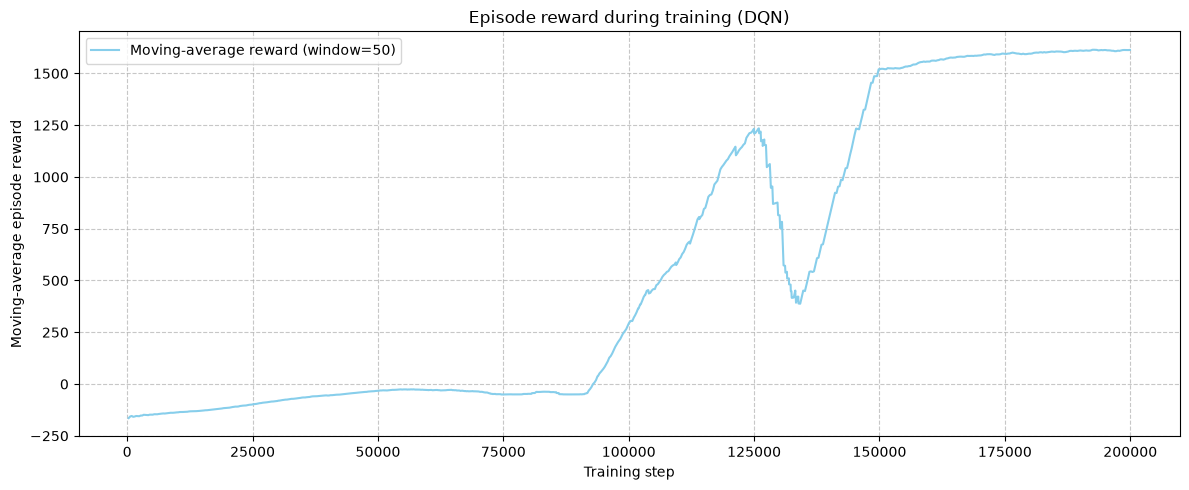

In [8]:
N_ROLLING = 50
if len(ep_rewards):
    rolled = [np.mean(ep_rewards[max(0, i-N_ROLLING+1):i+1]) for i in range(len(ep_rewards))]
    print(f"Last 10 episode rewards: {np.round(ep_rewards[-10:],1)}")
    plt.figure(figsize=(12, 5))
    plt.plot(ep_lengths_steps, rolled, color='skyblue',
             label=f"Moving-average reward (window={N_ROLLING})")
    plt.xlabel("Training step"); plt.ylabel("Moving-average episode reward")
    plt.title("Episode reward during training (DQN)")
    plt.legend(); plt.grid(True, ls='--', alpha=.7); plt.tight_layout(); plt.show()
else:
    print("No episodes recorded.")


## 8. Greedy evaluation

Deterministic (ε = 0) rollouts from the disk at rest at the bottom, using the
best checkpoint. Reports the same metrics as your tabular/RBF notebooks so the
three approaches are directly comparable:
*reward*, *time-at-top* (primary quality metric), and *success rate*.

In [7]:
print("\n--- START EVALUATION WITH BEST MODEL (DQN) ---")

def make_eval_env(render_mode):
    e = UnbalancedDisk(dt=DT, umax=UMAX, render_mode=render_mode)
    e = UnbalancedDiskResetWrapper(e)
    e = gym.wrappers.TimeLimit(e, max_episode_steps=MAX_EP_STEPS)
    return e

def load_qnet(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    cfg = ckpt['cfg']
    net = QNet(cfg['state_dim'], int(cfg['n_actions']), cfg['hidden']).to(DEVICE)
    net.load_state_dict(ckpt['model']); net.eval()
    return net


def greedy_action(net, obs_raw):
    with torch.no_grad():
        s = torch.as_tensor(encode_obs(obs_raw), device=DEVICE).unsqueeze(0)
        return int(torch.argmax(net(s), dim=1).item())

def run_episode(env, net, start=(0.0, 0.0), render=False, fps=30):
    base = env.unwrapped
    base.set_th, base.set_omega = float(start[0]), float(start[1])
    obs_raw, _ = env.reset()
    base.set_th, base.set_omega = None, None

    total_r, steps, done, top_steps = 0.0, 0, False, 0
    while not done:
        a = greedy_action(net, obs_raw)
        obs_raw, r, terminated, truncated, _ = env.step(a)
        total_r += r; steps += 1; done = terminated or truncated
        if abs(((base.th - np.pi + np.pi) % (2*np.pi)) - np.pi) < TOP_TOL:
            top_steps += 1
        if render:
            env.render(); time.sleep(1/fps)
    ended_at_top = abs(((base.th - np.pi + np.pi) % (2*np.pi)) - np.pi) < TOP_TOL
    return total_r, steps, top_steps/max(steps,1), ended_at_top


if os.path.exists('DQN_swingup_v2.pt'):
    net = load_qnet('DQN_swingup_v2.pt')
    START = (0.0, 0.0)

    np.random.seed(EVAL_SEED); torch.manual_seed(EVAL_SEED)
    env_stats = make_eval_env(render_mode=None)
    rewards, lengths, toptime, ended = [], [], [], []
    for _ in range(NUM_EVAL_EPS):
        r, l, ft, et = run_episode(env_stats, net, start=START)
        rewards.append(r); lengths.append(l); toptime.append(ft); ended.append(et)
    env_stats.close()
    rewards, lengths, toptime = map(np.array, (rewards, lengths, toptime))

    print(f"\n--- EVALUATION RESULTS ({NUM_EVAL_EPS} greedy episodes, fixed start at bottom) ---")
    print(f"Reward      : mean {rewards.mean():8.2f} | std {rewards.std():7.2f} | "
          f"median {np.median(rewards):8.2f} | min {rewards.min():8.2f} | max {rewards.max():8.2f}")
    print(f"Length      : mean {lengths.mean():8.1f} | min {int(lengths.min())} | max {int(lengths.max())}")
    print(f"Time at top : mean {100*toptime.mean():5.1f}%   <- primary quality metric")
    print(f"Success     : {100*np.mean(ended):5.1f}% of episodes ended at the top")

    np.random.seed(EVAL_SEED)
    env_watch = make_eval_env(render_mode='human')
    for i in range(NUM_WATCH_EPS):
        r, l, ft, et = run_episode(env_watch, net, start=START, render=True)
        print(f"Watch episode {i+1}: length={l}, reward={r:.2f}, time-at-top={100*ft:.0f}%")
    env_watch.close()
else:
    print(f"Error: checkpoint 'DQN_swingup_v1.pt' not found. Run training first.")



--- START EVALUATION WITH BEST MODEL (DQN) ---

--- EVALUATION RESULTS (50 greedy episodes, fixed start at bottom) ---
Reward      : mean  1708.42 | std    0.00 | median  1708.42 | min  1708.42 | max  1708.42
Length      : mean    300.0 | min 300 | max 300
Time at top : mean  90.3%   <- primary quality metric
Success     : 100.0% of episodes ended at the top
Watch episode 1: length=300, reward=1708.42, time-at-top=90%
Watch episode 2: length=300, reward=1708.42, time-at-top=90%
Watch episode 3: length=300, reward=1708.42, time-at-top=90%


## Notes, tuning & deployment

**If it learns slowly / unstably, try in this order:**
1. **Reward scale.** Big rewards → big TD targets → unstable nets. If your
   `reward_fun` spikes to tens/hundreds, scale rewards down (e.g. `r *= 0.1`)
   when pushing to the buffer, or lower `GRAD_CLIP`.
2. **Target sync.** `TARGET_SYNC` too small ⇒ chasing target (slide 51);
   too large ⇒ slow. Try 500–2000.
3. **ε / curriculum length.** If it never discovers the top, lengthen
   `EPS_DECAY_STEPS` and/or `CURRICULUM_STEPS`, or start the curriculum nearer
   the top for longer.
4. **Double DQN** (one-line change): decouple action selection from evaluation
   to reduce the max-overestimation bias —
   `a* = argmax_u Qonline(s2,u); target = r + γ Qtarget(s2,a*)`.
5. **Capacity.** Increase `HIDDEN` to `(256,256)` if underfitting.

**Deployment on hardware (`runExp.py` / `UnbalancedDiskExp.py`).** Swap the
Q-table lookup for:
```python
ckpt = torch.load('DQN_swingup_v1.pt', map_location='cpu')
net  = QNet(**{k: ckpt['cfg'][k] for k in ('state_dim','n_actions','hidden')})
net.load_state_dict(ckpt['model']); net.eval()

def policy(obs_raw):                      # obs_raw = [theta, omega] from get_obs()
    import numpy as np, torch
    s = np.array([np.sin(obs_raw[0]), np.cos(obs_raw[0]), obs_raw[1]/ckpt['cfg']['omega_scale']],
                 dtype=np.float32)
    with torch.no_grad():
        return int(torch.argmax(net(torch.as_tensor(s)[None])).item())
```
Make sure `num_actions`, `discrete_action_map`, `dt` and the observation handling
match between training and `UnbalancedDiskExp.py` — the same warning as before.
